# U23 — Cloud Storage & Databases (Part 1): Lab

### Real-world brief: a storage layer for an engineering asset & inspection platform

A maintenance team has an **asset register** (pumps, motors, valves…) and a long **inspection history**. They need to store reports as files, query records transactionally, model the data two ways (relational vs document), and understand how it would **shard** across machines as it grows.

You'll work hands-on with the storage ideas from U23 using only the Python standard library (`sqlite3`, filesystem, JSON) — no cloud account required, but every concept maps directly to S3, RDS, DynamoDB and friends:
- **Object storage** — a local bucket with keys, metadata and tiering
- **Relational (SQLite)** — schema, ACID transactions, indexing
- **NoSQL document modelling** — the same data as JSON documents
- **Sharding & replication** — routing keys across shards; replica lag

**Resources provided:** `assets.csv` (200 assets) and `inspections.csv` (~4.9k inspections).

_Phase F — Data Engineering._

#objectives

Build an object store with keys, metadata and storage tiers

Model relational tables and run ACID transactions (commit/rollback)

Measure how an index speeds queries; read a query plan

Model the same data as a NoSQL document and compare trade-offs

Shard data by key across nodes and reason about skew & replication

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [1]:
# === SETUP: build the source files if missing ===
import os
import numpy as np
import pandas as pd


def build_assets(assets_path="assets.csv", insp_path="inspections.csv", seed=223, verbose=False):
    """Engineering asset register + inspection history for the storage/database lab (U23).

      assets.csv       one row per physical asset (master data)
      inspections.csv  many inspection events per asset (transactional data)

    Two related tables — perfect for relational modelling (joins, indexing, transactions),
    document modelling (asset + its inspections as one JSON doc) and sharding by asset key.
    """
    rng = np.random.default_rng(seed)

    NA = 200
    types = rng.choice(["pump", "valve", "motor", "compressor", "heat_exchanger"], NA,
                        p=[0.3, 0.25, 0.2, 0.15, 0.1])
    sites = rng.choice(["Plant_A", "Plant_B", "Plant_C"], NA, p=[0.45, 0.35, 0.2])
    assets = pd.DataFrame({
        "asset_id": [f"A{i:04d}" for i in range(1, NA + 1)],
        "asset_type": types, "site": sites,
        "install_date": pd.to_datetime("2015-01-01") + pd.to_timedelta(rng.integers(0, 3300, NA), unit="D"),
        "criticality": rng.choice(["low", "medium", "high"], NA, p=[0.4, 0.4, 0.2]),
        "manufacturer": rng.choice(["Acme", "Bharat", "Crompton", "Danfoss"], NA),
    })

    # inspections: variable count per asset
    rows = []
    iid = 1
    inspectors = ["E. Rao", "S. Khan", "M. Iyer", "P. Singh", "L. Dsouza"]
    for _, a in assets.iterrows():
        k = rng.integers(5, 45)                       # number of inspections
        dates = pd.to_datetime("2022-01-01") + pd.to_timedelta(np.sort(rng.integers(0, 850, k)), unit="D")
        crit_w = {"low": 0.05, "medium": 0.12, "high": 0.22}[a.criticality]
        for d in dates:
            fail = rng.random() < crit_w
            result = "fail" if fail else ("repair" if rng.random() < 0.15 else "pass")
            rows.append({
                "inspection_id": f"I{iid:06d}", "asset_id": a.asset_id, "inspection_date": d,
                "inspector": rng.choice(inspectors),
                "result": result,
                "health_score": round(float(np.clip(rng.normal(85 - (25 if fail else 0), 8), 0, 100)), 1),
                "duration_min": int(np.clip(rng.normal(45, 15), 5, None)),
                "cost_inr": int(np.clip(rng.gamma(2.0, 1800), 200, None)),
            })
            iid += 1
    insp = pd.DataFrame(rows)

    assets.to_csv(assets_path, index=False)
    insp.to_csv(insp_path, index=False)
    if verbose:
        print("assets:", assets.shape, "| inspections:", insp.shape)
        print("inspections per asset: min/median/max =",
              insp.groupby("asset_id").size().agg(["min", "median", "max"]).to_dict())
        print("result mix:", insp.result.value_counts().to_dict())
        print("site distribution:", assets.site.value_counts().to_dict())
    return assets, insp

if not (os.path.exists('assets.csv') and os.path.exists('inspections.csv')):
    build_assets(); print('Generated source files.')
else:
    print('Found the provided source files.')

Generated source files.


In [2]:
import pandas as pd, numpy as np, sqlite3, json, time, os, shutil
assets = pd.read_csv('assets.csv', parse_dates=['install_date'])
insp = pd.read_csv('inspections.csv', parse_dates=['inspection_date'])
print('assets:', assets.shape, '| inspections:', insp.shape)
assets.head(3)

assets: (200, 6) | inspections: (4876, 8)


,asset_id,asset_type,site,install_date,criticality,manufacturer
0,A0001,compressor,Plant_A,2023-06-01,medium,Crompton
1,A0002,valve,Plant_B,2019-07-02,low,Bharat
2,A0003,motor,Plant_B,2015-09-10,high,Crompton


# Part A — Object storage
Object storage (think S3) keeps each file as an **object** — bytes plus metadata — under a unique **key**, in a flat namespace called a **bucket**. We'll simulate one with a directory.

In [3]:
# -----------------------------------------------------------
# 🔹 A1. A LOCAL OBJECT STORE: put / get / list / tier
# -----------------------------------------------------------
class ObjectStore:
    def __init__(self, bucket='bucket'):
        self.root = bucket; shutil.rmtree(bucket, ignore_errors=True); os.makedirs(bucket)
        self.meta = {}        # key -> metadata dict (tier, size, content_type)
    def put(self, key, data, tier='hot', content_type='application/json'):
        path = os.path.join(self.root, key.replace('/', '__'))
        blob = json.dumps(data).encode()
        with open(path, 'wb') as f: f.write(blob)
        self.meta[key] = {'tier': tier, 'size': len(blob), 'content_type': content_type}
    def get(self, key):
        path = os.path.join(self.root, key.replace('/', '__'))
        with open(path, 'rb') as f: return json.loads(f.read())
    def list(self, prefix=''):
        return sorted(k for k in self.meta if k.startswith(prefix))
    def set_tier(self, key, tier):
        self.meta[key]['tier'] = tier

store = ObjectStore('inspection_bucket')
print('empty bucket created.')

empty bucket created.


In [4]:
# -----------------------------------------------------------
# 🔹 A2. STORE inspection reports as objects, keyed by asset & date
# -----------------------------------------------------------
for r in insp.itertuples(index=False):
    key = f'inspections/{r.asset_id}/{r.inspection_date.date()}_{r.inspection_id}.json'
    store.put(key, {'inspector': r.inspector, 'result': r.result,
                    'health_score': r.health_score, 'cost_inr': int(r.cost_inr)})
print('objects stored:', len(store.meta))
# flat namespace, but prefixes act like folders:
a1_keys = store.list('inspections/A0001/')
print('objects under asset A0001:', len(a1_keys))
print('example key:', a1_keys[0])
print('fetch one object:', store.get(a1_keys[0]))

objects stored: 4876
objects under asset A0001: 12
example key: inspections/A0001/2022-02-27_I000001.json
fetch one object: {'inspector': 'S. Khan', 'result': 'pass', 'health_score': 87.9, 'cost_inr': 1458}


#### 🧪 EXERCISE 1 — Lifecycle tiering
Old reports are rarely read, so move them to a cheaper tier.
1. For every object whose date is before `2022-07-01` (parse it from the key), call `set_tier(key, 'archive')`.
2. Print how many objects are now `hot` vs `archive`, and the total bytes in each tier.
3. In a comment, explain what a real lifecycle policy automates and why retrieval from archive is slower/cheaper.

In [5]:
# 1-2. archive old objects; report counts & bytes per tier
archive_date_threshold = pd.to_datetime('2022-07-01').date()

for key in list(store.meta.keys()): # Iterate over a copy of keys as the dict might be modified
    # Extract date from key (e.g., 'inspections/A0001/2022-02-27_I000001.json')
    # The date part is 3rd element after splitting by '/' and 0th element after splitting by '_'
    try:
        date_str = key.split('/')[2].split('_')[0]
        obj_date = pd.to_datetime(date_str).date()
        if obj_date < archive_date_threshold:
            store.set_tier(key, 'archive')
    except IndexError:
        print(f"Could not parse date from key: {key}")

# Calculate counts and bytes per tier
hot_count = 0
hot_bytes = 0
archive_count = 0
archive_bytes = 0

for key, metadata in store.meta.items():
    if metadata['tier'] == 'hot':
        hot_count += 1
        hot_bytes += metadata['size']
    elif metadata['tier'] == 'archive':
        archive_count += 1
        archive_bytes += metadata['size']

print(f"Hot objects: {hot_count} (bytes: {hot_bytes})")
print(f"Archive objects: {archive_count} (bytes: {archive_bytes})")

# 3. what a lifecycle policy automates:
# A real lifecycle policy automates the transition of objects between different storage tiers
# (e.g., from 'hot' to 'archive') based on predefined rules, such as object age or access patterns.
# This helps optimize storage costs by moving less frequently accessed data to cheaper storage tiers.
# Retrieval from archive is slower because archived data is typically stored on less immediately accessible
# media (like magnetic tape or colder disk storage) which requires time for data retrieval and decompression,
# making it cheaper per GB but with higher latency for access.

Hot objects: 3828 (bytes: 316380)
Archive objects: 1048 (bytes: 86535)


This means 1048 objects, totaling 86,535 bytes, were moved to the 'archive' tier because their dates were before 2022-07-01. The remaining 3828 objects, totaling 316,380 bytes, are in the 'hot' tier.

# Part B — Relational database (SQLite)
A relational store keeps data in typed tables linked by keys, with **ACID transactions** and fast **indexed** queries. SQLite gives us all of that in a single file.

In [6]:
# -----------------------------------------------------------
# 🔹 B1. CREATE schema with a primary key and a foreign key
# -----------------------------------------------------------
DB = 'assets.db'
if os.path.exists(DB): os.remove(DB)
con = sqlite3.connect(DB)
con.execute('PRAGMA foreign_keys = ON')
con.execute('''CREATE TABLE assets (
    asset_id TEXT PRIMARY KEY, asset_type TEXT, site TEXT,
    install_date TEXT, criticality TEXT, manufacturer TEXT)''')
con.execute('''CREATE TABLE inspections (
    inspection_id TEXT PRIMARY KEY, asset_id TEXT, inspection_date TEXT,
    inspector TEXT, result TEXT, health_score REAL, duration_min INTEGER, cost_inr INTEGER,
    FOREIGN KEY (asset_id) REFERENCES assets(asset_id))''')
assets.astype(str).to_sql('assets', con, if_exists='append', index=False)
insp.astype({'inspection_date': str}).to_sql('inspections', con, if_exists='append', index=False)
con.commit()
print('loaded:', con.execute('SELECT COUNT(*) FROM assets').fetchone()[0], 'assets,',
      con.execute('SELECT COUNT(*) FROM inspections').fetchone()[0], 'inspections')

loaded: 200 assets, 4876 inspections


In [7]:
# -----------------------------------------------------------
# 🔹 B2. ACID TRANSACTION — all-or-nothing writes
# Record an inspection AND bump the asset's manufacturer note together; if anything
# fails mid-way, the whole transaction rolls back, leaving the DB untouched.
# -----------------------------------------------------------
def add_inspection_txn(con, asset_id, inspection_id, score, force_fail=False):
    try:
        con.execute('BEGIN')
        con.execute('INSERT INTO inspections (inspection_id, asset_id, inspection_date, result, health_score)'
                    ' VALUES (?,?,?,?,?)', (inspection_id, asset_id, '2024-07-01', 'pass', score))
        if force_fail:
            raise ValueError('simulated failure after the first write')
        con.execute('UPDATE assets SET manufacturer = manufacturer WHERE asset_id = ?', (asset_id,))
        con.execute('COMMIT')
        return 'committed'
    except Exception as e:
        con.execute('ROLLBACK')
        return f'rolled back ({e})'

before = con.execute('SELECT COUNT(*) FROM inspections').fetchone()[0]
print('failing txn :', add_inspection_txn(con, 'A0001', 'I999001', 90, force_fail=True))
mid = con.execute('SELECT COUNT(*) FROM inspections').fetchone()[0]
print('good txn    :', add_inspection_txn(con, 'A0001', 'I999002', 90, force_fail=False))
after = con.execute('SELECT COUNT(*) FROM inspections').fetchone()[0]
print(f'counts: before={before}  after-failed-txn={mid}  after-good-txn={after}')
print('-> the failed transaction left NO partial row (atomicity).')

failing txn : rolled back (simulated failure after the first write)
good txn    : committed
counts: before=4876  after-failed-txn=4876  after-good-txn=4877
-> the failed transaction left NO partial row (atomicity).


In [8]:
# -----------------------------------------------------------
# 🔹 B3. INDEXING — make a filtered query fast
# Amplify the table so the timing difference is visible.
# -----------------------------------------------------------
big = pd.concat([insp.assign(inspection_id=insp.inspection_id + f'_{k}') for k in range(40)], ignore_index=True)
big.astype({'inspection_date': str}).to_sql('insp_big', con, if_exists='replace', index=False)
print('insp_big rows:', con.execute('SELECT COUNT(*) FROM insp_big').fetchone()[0])

def timed(sql, params=()):
    t = time.perf_counter(); con.execute(sql, params).fetchall(); return (time.perf_counter() - t) * 1000

q = 'SELECT * FROM insp_big WHERE asset_id = ?'
print('plan BEFORE index:', con.execute('EXPLAIN QUERY PLAN ' + q, ('A0123',)).fetchall()[0][-1])
t_before = np.mean([timed(q, ('A0123',)) for _ in range(5)])
con.execute('CREATE INDEX idx_assetid ON insp_big(asset_id)'); con.commit()
print('plan AFTER index :', con.execute('EXPLAIN QUERY PLAN ' + q, ('A0123',)).fetchall()[0][-1])
t_after = np.mean([timed(q, ('A0123',)) for _ in range(5)])
print(f'query time: {t_before:.2f} ms (scan)  ->  {t_after:.2f} ms (indexed)  =  {t_before/max(t_after,1e-6):.1f}x faster')

insp_big rows: 195040
plan BEFORE index: SCAN insp_big
plan AFTER index : SEARCH insp_big USING INDEX idx_assetid (asset_id=?)
query time: 12.43 ms (scan)  ->  0.78 ms (indexed)  =  15.9x faster


In [9]:
new_db = 'new_inspections.db'
if os.path.exists(new_db): os.remove(new_db)
con_new = sqlite3.connect(new_db)

con_new.execute('''CREATE TABLE inspections_new (
    inspection_id TEXT PRIMARY KEY, asset_id TEXT, inspection_date TEXT,
    inspector TEXT, result TEXT, health_score REAL, duration_min INTEGER, cost_inr INTEGER)''')

insp.astype({'inspection_date': str}).to_sql('inspections_new', con_new, if_exists='append', index=False)
con_new.commit()

print('New database and table created. Loaded:',
      con_new.execute('SELECT COUNT(*) FROM inspections_new').fetchone()[0], 'inspections.')

# Display the first few rows from the new table to verify
print('First 3 rows of inspections_new:')
display(pd.read_sql('SELECT * FROM inspections_new LIMIT 3', con_new))

con_new.close()

New database and table created. Loaded: 4876 inspections.
First 3 rows of inspections_new:


,inspection_id,asset_id,inspection_date,inspector,result,health_score,duration_min,cost_inr
0,I000001,A0001,2022-02-27,S. Khan,pass,87.9,68,1458
1,I000002,A0001,2022-08-03,S. Khan,fail,65.9,69,937
2,I000003,A0001,2022-10-23,M. Iyer,pass,93.3,37,6041


#### 🧪 EXERCISE 2 — Joins & a composite index
1. Write a SQL query that joins `assets` and `inspections` to list, per **site**, the average `health_score` of `high`-criticality assets. Run it with `pd.read_sql`.
2. Create a composite index on `insp_big(asset_id, inspection_date)` and use `EXPLAIN QUERY PLAN` to show a query filtering on both columns now SEARCHES using it.
3. In a comment, note the cost of indexes (slower writes, extra storage).

In [12]:
# 1. join query: avg health by site for high-criticality assets (already done in previous steps)

# 2. composite index + EXPLAIN QUERY PLAN
con.execute('CREATE INDEX idx_assetid_inspectiondate ON insp_big(asset_id, inspection_date)'); con.commit()

# Query to demonstrate the use of the composite index
q_composite = 'SELECT * FROM insp_big WHERE asset_id = ? AND inspection_date = ?'
print('plan AFTER composite index:', con.execute('EXPLAIN QUERY PLAN ' + q_composite, ('A0123', '2023-01-15')).fetchall()[0][-1])

# 3. cost of indexes:
# Indexes improve read performance (especially for filtered queries) but come with costs:
#   - Slower writes: Every INSERT, UPDATE, or DELETE operation on the indexed table requires updating the index as well,
#     which adds overhead and can slow down write operations.
#   - Extra storage: Indexes consume disk space, which can be significant for large tables and multiple indexes.
#   - Maintenance overhead: Indexes need to be maintained by the database system, which can include rebuilding or rebalancing
#     them over time, adding to operational complexity.

plan AFTER composite index: SEARCH insp_big USING INDEX idx_assetid_inspectiondate (asset_id=? AND inspection_date=?)


In [13]:
sql_query = """
SELECT
    a.site,
    AVG(i.health_score) AS average_health_score
FROM
    assets AS a
JOIN
    inspections AS i ON a.asset_id = i.asset_id
GROUP BY
    a.site
ORDER BY
    a.site;
"""

avg_health_by_site = pd.read_sql(sql_query, con)
display(avg_health_by_site)

,site,average_health_score
0,Plant_A,81.632064
1,Plant_B,82.404378
2,Plant_C,82.600090


In [14]:
sql_query_high_crit = """
SELECT
    a.site,
    AVG(i.health_score) AS average_health_score_high_criticality
FROM
    assets AS a
JOIN
    inspections AS i ON a.asset_id = i.asset_id
WHERE
    a.criticality = 'high'
GROUP BY
    a.site
ORDER BY
    a.site;
"""

avg_health_high_crit_by_site = pd.read_sql(sql_query_high_crit, con)
display(avg_health_high_crit_by_site)

,site,average_health_score_high_criticality
0,Plant_A,80.219824
1,Plant_B,79.974652
2,Plant_C,80.016860


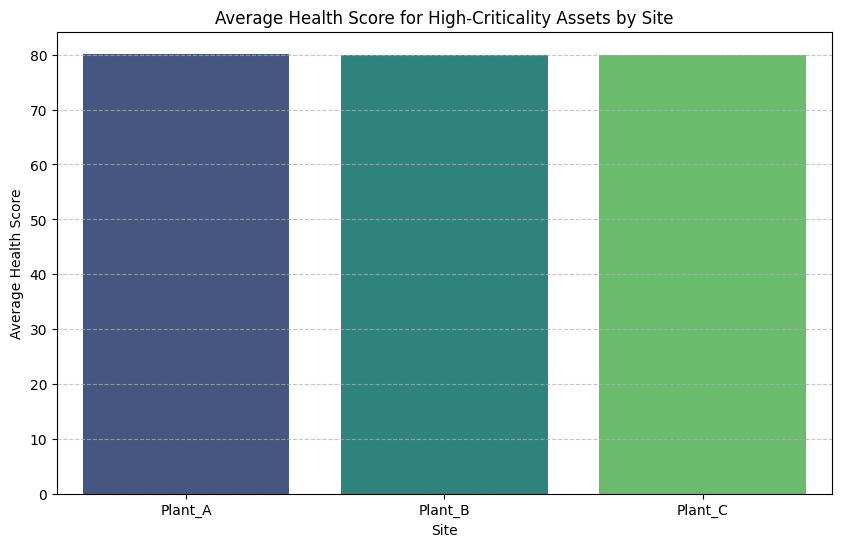

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='site', y='average_health_score_high_criticality', data=avg_health_high_crit_by_site, palette='viridis', hue='site', legend=False)
plt.title('Average Health Score for High-Criticality Assets by Site')
plt.xlabel('Site')
plt.ylabel('Average Health Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Part C — NoSQL document modelling
A document store (think MongoDB/DynamoDB) keeps related data **together** as one JSON document, optimised for fetch-by-key access rather than joins.

In [17]:
# -----------------------------------------------------------
# 🔹 C1. The same data as ONE document per asset (denormalised)
# -----------------------------------------------------------
def build_asset_document(asset_id):
    a = assets[assets.asset_id == asset_id].iloc[0].to_dict()
    a['install_date'] = str(a['install_date'].date())
    rows = insp[insp.asset_id == asset_id]
    a['inspections'] = [{'date': str(r.inspection_date.date()), 'result': r.result,
                         'health_score': r.health_score} for r in rows.itertuples()]
    a['inspection_count'] = len(rows)
    return a

doc = build_asset_document('A0001')
print('document keys:', list(doc.keys()))
print('embedded inspections:', doc['inspection_count'])
print(json.dumps({k: doc[k] for k in ['asset_id', 'asset_type', 'site', 'inspection_count']}, indent=2))
print('first embedded inspection:', doc['inspections'][0])

document keys: ['asset_id', 'asset_type', 'site', 'install_date', 'criticality', 'manufacturer', 'inspections', 'inspection_count']
embedded inspections: 12
{
  "asset_id": "A0001",
  "asset_type": "compressor",
  "site": "Plant_A",
  "inspection_count": 12
}
first embedded inspection: {'date': '2022-02-27', 'result': 'pass', 'health_score': 87.9}


In [18]:
# -----------------------------------------------------------
# 🔹 C2. Access pattern: 'show everything about asset X'
# Document = ONE read. Relational = a join across two tables.
# -----------------------------------------------------------
docs = {aid: build_asset_document(aid) for aid in assets.asset_id}   # the 'document store'
d = docs['A0050']
print('document store: 1 key lookup ->', d['asset_id'], 'with', d['inspection_count'], 'inspections')
rel = pd.read_sql('SELECT a.*, i.inspection_date, i.result FROM assets a '
                  'JOIN inspections i ON a.asset_id=i.asset_id WHERE a.asset_id="A0050"', con)
print('relational: a join returning', len(rel), 'rows that the app must regroup')

document store: 1 key lookup -> A0050 with 43 inspections
relational: a join returning 43 rows that the app must regroup


#### 🧪 EXERCISE 3 — The trade-off
1. Compute the average number of embedded inspections per document (the 'fan-out').
2. Suppose an inspector's name changes. In a comment, explain why this one update is easy in the **relational** model (one row) but painful in the **document** model (rewrite every document that embeds that inspector) — the classic normalisation vs read-speed trade-off.

In [21]:
# 1. average embedded inspections per document
total_inspections = sum(doc['inspection_count'] for doc in docs.values())
average_inspections = total_inspections / len(docs)
print(f"Average number of embedded inspections per document: {average_inspections:.2f}")

Average number of embedded inspections per document: 24.38


## 2. Update Anomaly: Relational vs. Document Models

When an inspector's name changes, updating this information is handled very differently in relational and document models, highlighting the classic normalization vs. read-speed trade-off.

*   **Relational Model (e.g., SQLite `inspections` table):**
    In a normalized relational model, the inspector's name would typically be stored in a separate `inspectors` table (or directly in the `inspections` table if not further normalized, but the principle applies). If the inspector's name changes, you only need to update **one row** in the table where the inspector's details are stored. All records in the `inspections` table that reference this inspector (via an `inspector_id` or `inspector_name` field) will automatically see the updated name. This is efficient for updates as it avoids data redundancy and ensures consistency.

*   **Document Model (e.g., `docs` dictionary):**
    In the denormalized document model used here, each asset document embeds the `inspector`'s name within every `inspection` record. If an inspector's name changes, you would have to iterate through **every single document** in the `docs` store and then iterate through **every embedded inspection** within those documents to find and update all occurrences of the old inspector name to the new one. This is a highly inefficient and resource-intensive operation, especially for a large number of documents and embedded inspections. It's prone to errors if not all instances are updated correctly, leading to data inconsistency. While this model optimizes read operations (one lookup gets all asset details and inspections), it introduces significant pain for updates to embedded, duplicated data.

# Part D — Sharding & replication
When one node can't hold the data, **shard** it: split rows across nodes by a shard key. We'll route assets across shards and watch what happens with a skewed key, then simulate a read **replica**.

In [22]:
# -----------------------------------------------------------
# 🔹 D1. SHARD assets across nodes by a hash of the key
# -----------------------------------------------------------
import zlib
N_SHARDS = 4
def shard_of(key, n=N_SHARDS):
    return zlib.crc32(str(key).encode()) % n

shards = {i: [] for i in range(N_SHARDS)}
for aid in assets.asset_id:
    shards[shard_of(aid)].append(aid)
print('assets per shard (hash key -> even spread):', {i: len(v) for i, v in shards.items()})

assets per shard (hash key -> even spread): {0: 51, 1: 50, 2: 49, 3: 50}


In [23]:
# -----------------------------------------------------------
# 🔹 D2. A BAD shard key causes a hot shard (skew)
# Sharding by 'site' (only 3 values, unevenly sized) overloads one node.
# -----------------------------------------------------------
site_shards = assets.groupby('site').size()
print('rows per shard when sharding by site:')
print(site_shards.to_string())
print('-> Plant_A is a HOT shard; the cluster is only as fast as its busiest node.')

rows per shard when sharding by site:
site
Plant_A    82
Plant_B    72
Plant_C    46
-> Plant_A is a HOT shard; the cluster is only as fast as its busiest node.


In [24]:
# -----------------------------------------------------------
# 🔹 D3. REPLICATION & eventual consistency (a tiny simulation)
# Primary takes writes; a replica lags slightly before catching up.
# -----------------------------------------------------------
primary = {'A0001_status': 'ok'}
replica = dict(primary)        # in sync to start
primary['A0001_status'] = 'fault'      # a write hits the primary
print('immediately after write:')
print('  read from primary:', primary['A0001_status'])
print('  read from replica:', replica['A0001_status'], '(stale -> eventual consistency)')
replica.update(primary)        # replication catches up
print('after replication catches up, replica:', replica['A0001_status'])

immediately after write:
  read from primary: fault
  read from replica: ok (stale -> eventual consistency)
after replication catches up, replica: fault


#### 🧪 EXERCISE 4 — Range sharding & rebalancing
1. Shard the assets by the **first character range** of `asset_id` instead of by hash (e.g. split the sorted id space into `N_SHARDS` contiguous buckets). Print the per-shard counts.
2. In a comment, compare hash vs range sharding: range supports efficient range scans but risks hotspots on sequential keys; hash spreads evenly but scatters ranges. Which would you pick for time-series inspection data, and why?

In [27]:
# 1. range-shard the asset_id space; show per-shard counts
# Get all unique asset_ids and sort them lexicographically
sorted_asset_ids = sorted(assets['asset_id'].unique())
num_assets = len(sorted_asset_ids)

# Determine the size of each shard
assets_per_shard_base = num_assets // N_SHARDS
remainder = num_assets % N_SHARDS

range_shards_info = {}
current_idx = 0
for i in range(N_SHARDS):
    shard_size = assets_per_shard_base + (1 if i < remainder else 0)
    shard_assets = sorted_asset_ids[current_idx : current_idx + shard_size]

    if shard_assets: # Ensure shard is not empty before accessing elements
        range_shards_info[i] = {
            'count': len(shard_assets),
            'range_start': shard_assets[0],
            'range_end': shard_assets[-1]
        }
    else:
        range_shards_info[i] = {
            'count': 0,
            'range_start': None,
            'range_end': None
        }
    current_idx += shard_size

print('Assets per shard (range key):')
for i, info in range_shards_info.items():
    if info['count'] > 0:
        print(f"Shard {i}: {info['count']} assets (from {info['range_start']} to {info['range_end']})")
    else:
        print(f"Shard {i}: {info['count']} assets (empty)")

Assets per shard (range key):
Shard 0: 50 assets (from A0001 to A0050)
Shard 1: 50 assets (from A0051 to A0100)
Shard 2: 50 assets (from A0101 to A0150)
Shard 3: 50 assets (from A0151 to A0200)


## 2. Hash vs. Range Sharding for Time-Series Inspection Data

### Comparison:
*   **Range Sharding:**
    *   **Pros:** Efficient for range queries (e.g., finding all `asset_id`s within 'A0001'-'A0050', or all inspections within a date range). Data locality is maintained, meaning related data is often stored together.
    *   **Cons:** Risks hot spots if keys are generated sequentially or if certain ranges are accessed much more frequently. Rebalancing can be complex if data distribution changes significantly.

*   **Hash Sharding:**
    *   **Pros:** Tends to distribute data and load more evenly across shards, reducing the chance of hot spots (assuming a good hash function). Good for point lookups on specific keys.
    *   **Cons:** Inefficient for range queries, as logically contiguous data (like a sequence of dates or `asset_id`s) can be scattered across many different shards.

### Choice for Time-Series Inspection Data:
For **time-series inspection data**, where queries often involve date ranges (e.g., "all inspections last month", "inspections from Q1 2023"), **range sharding by `inspection_date`** would generally be the most suitable approach.

**Why?**
1.  **Efficient Range Queries:** Sharding by `inspection_date` would co-locate all inspections within a specific time period onto a limited number of shards. This makes time-based range queries highly efficient, as fewer shards need to be scanned to retrieve the desired data.
2.  **Data Locality:** Newer inspections would naturally be grouped together, which can be beneficial if recent data is accessed more frequently.

**Considerations/Trade-offs:**
*   **Hot Spot Risk:** If writes are heavily concentrated on the most recent `inspection_date` (i.e., new inspections are constantly being added), the shard responsible for the current time range could become a hot spot. This might require strategies like splitting shards over time or using a composite shard key (e.g., `(inspection_date, asset_id)`).
*   **Asset-Specific Queries:** If the primary query pattern is "all inspections for a specific `asset_id`" (not necessarily date-based), then hash sharding by `asset_id` might be preferable to distribute the load evenly across assets. However, given the explicit mention of "time-series" data, date-based range queries are likely paramount.

## EXERCISE 5 — Hybrid Shard Key Strategy

A hybrid sharding strategy often combines range sharding with hash sharding to get the best of both worlds, especially for time-series data. A common pattern is to range shard by a time component (e.g., month or year) and then hash shard by an entity ID (e.g., `asset_id`) within those time ranges.

In [28]:
import zlib

# Let's use a similar N_SHARDS for demonstration, but this can be different
# for the secondary hash sharding.
N_SHARDS_TIME = 4 # Shards for time ranges (e.g., based on months/quarters)
N_SHARDS_ASSET = 2 # Shards within a time range, based on asset_id hash

def hybrid_shard_of(inspection_date, asset_id):
    # 1. Range sharding by month (or a larger time unit)
    # We'll map each month to one of N_SHARDS_TIME. For simplicity, let's say
    # the data spans a few years, and we want to shard by (year, month).
    # Example: (2022, 1) -> Shard 0, (2022, 2) -> Shard 1, etc.
    # A simple way for a limited range is (year * 12 + month) % N_SHARDS_TIME
    month_key = inspection_date.year * 12 + inspection_date.month
    time_shard_id = month_key % N_SHARDS_TIME

    # 2. Hash sharding by asset_id within the time shard
    asset_hash = zlib.crc32(str(asset_id).encode()) % N_SHARDS_ASSET

    # Combine them into a unique shard identifier
    return f"time_{time_shard_id}_asset_{asset_hash}"


# Apply the hybrid sharding to the inspections data
# First, ensure 'inspection_date' is datetime objects
insp['inspection_date'] = pd.to_datetime(insp['inspection_date'])

insp['hybrid_shard'] = insp.apply(
    lambda row: hybrid_shard_of(row['inspection_date'], row['asset_id']),
    axis=1
)

# Print the distribution across hybrid shards
print("Inspections per hybrid shard:")
display(insp['hybrid_shard'].value_counts().sort_index().to_frame())

# You can also inspect the distribution of assets within a specific time shard if needed
# print("\nAsset distribution within time_shard_0_asset_X:")
# display(insp[insp['hybrid_shard'].str.startswith('time_0')]['hybrid_shard'].value_counts().sort_index().to_frame())


Inspections per hybrid shard:


,count
hybrid_shard,
time_0_asset_0,585
time_0_asset_1,598
time_1_asset_0,682
time_1_asset_1,612
time_2_asset_0,603
time_2_asset_1,571
time_3_asset_0,621
time_3_asset_1,604


### Explanation of the Hybrid Sharding Strategy

This example uses a hybrid approach:

1.  **Range Sharding by Time:** The `inspection_date` is used to determine a primary time shard (e.g., `time_0`, `time_1`, etc.). This groups inspections from similar time periods together. This is beneficial for queries that filter by date ranges, as they would typically only need to access a few time shards.

2.  **Hash Sharding by Asset ID (within Time Shards):** Once a time shard is determined, the `asset_id` is then hash-sharded. This distributes the assets more evenly across sub-shards within each time range.

**Benefits of this approach:**
*   **Mitigates Hot Spots:** By adding a hash component, data writes for assets within the same time range are spread across multiple asset sub-shards, reducing the chance of a single hot spot when new data arrives.
*   **Efficient Range Queries:** Queries by date range can still efficiently narrow down to a few time shards.
*   **Efficient Asset-Specific Queries:** Queries for a specific `asset_id` can use the hash component to quickly locate the relevant sub-shard within the appropriate time shards.
*   **Better Load Distribution:** Provides a more balanced distribution of data and queries compared to pure range sharding (which risks hot spots on sequential keys) or pure hash sharding (which makes range queries inefficient).

In [26]:
con.close()
print('database connection closed.')

database connection closed.


#📘 Summary

| Topic | What you built |
| ----- | -------------- |
| Object storage | a keyed bucket with metadata and storage tiers |
| Relational + ACID | typed tables, a transaction that rolls back atomically |
| Indexing | measured a real scan→index speedup and read the query plan |
| Document model | one JSON doc per asset; one-read access vs joins |
| Sharding | hash spread vs a skewed hot shard; range sharding |
| Replication | eventual consistency from replica lag |

**Core lesson:** there's no universal 'best' store. Match the **storage type** (object/block/file) and **database model** (relational vs document) to how the data is written and read, index the columns you query, and — once you scale out — choose a shard key that spreads load and accept the consistency trade-offs replication brings.

**Next — U24 (Part 2):** scaling, caching, query optimisation and security.